<a href="https://colab.research.google.com/github/beatrizmvtoledo11/house-prices-ml/blob/main/02_final_model_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
"""
Projeto: House Prices Prediction (Kaggle)
Objetivo: Prever o preço de imóveis com base em características estruturais.
Autor: Beatriz Morales Vilha Toledo
"""

'\nProjeto: House Prices Prediction (Kaggle)\nObjetivo: Prever o preço de imóveis com base em características estruturais.\nAutor: Beatriz Morales Vilha Toledo\n'

In [40]:
# IMPORTS
# manipulação de dados
import pandas as pd
import numpy as np
# visualização
import matplotlib.pyplot as plt
import seaborn as sns
# machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_style("whitegrid")

In [41]:
# UPLOAD DE DADOS
from google.colab import drive
drive.mount('/content/drive')  # conecta seu Drive ao Colab

train_path = "/content/drive/MyDrive/projeto_imoveis/train.csv"
test_path = "/content/drive/MyDrive/projeto_imoveis/test.csv"

X = pd.read_csv(train_path, index_col='Id')   # 'Id' vira índice (não entra no modelo)
X_test_full = pd.read_csv(test_path, index_col='Id')

print("Shape treino:", X.shape)
print("Shape teste:", X_test_full.shape)

print("\nColunas do dataset:")
print(X.columns)

# remove casas sem preço (não dá pra treinar sem resposta)
X.dropna(axis=0, subset=['SalePrice'], inplace=True)

y = X['SalePrice']            # o que queremos prever
y = np.log1p(y)
X = X.drop(['SalePrice'], axis=1)  # remove do conjunto de entrada

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    train_size=0.8,   # 80% para treino
    random_state=0    # garante resultados iguais toda vez
)

print("\nTreino:", X_train.shape)
print("Validação:", X_valid.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape treino: (1460, 80)
Shape teste: (1459, 79)

Colunas do dataset:
Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',

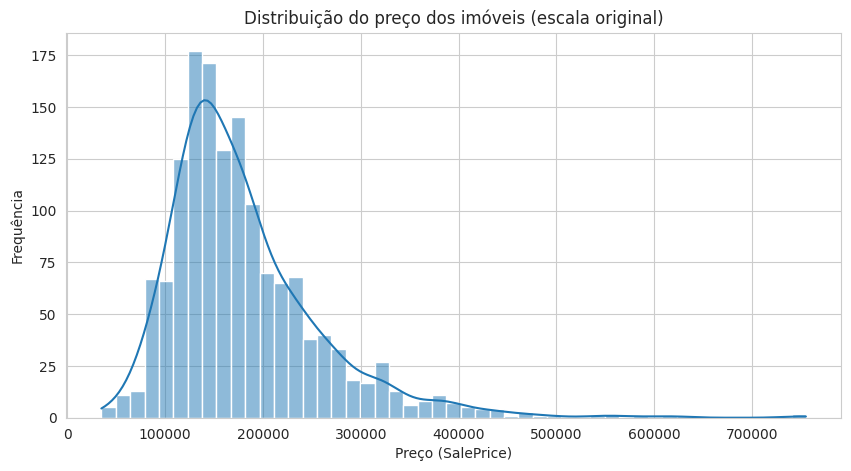

In [58]:
#ANÁLISE EXPLORATÓRIA (EDA)
y_original_scale = np.expm1(y)
plt.figure(figsize=(10,5))  # define o tamanho do gráfico
sns.histplot(y_original_scale, kde=True)   # y = SalePrice (preço dos imóveis), kde=True adiciona curva suave

plt.title("Distribuição do preço dos imóveis (escala original)")  # título do gráfico
plt.xlabel("Preço (SalePrice)")                                   # eixo X
plt.ylabel("Frequência")                                          # eixo Y
plt.grid(True)
plt.show()

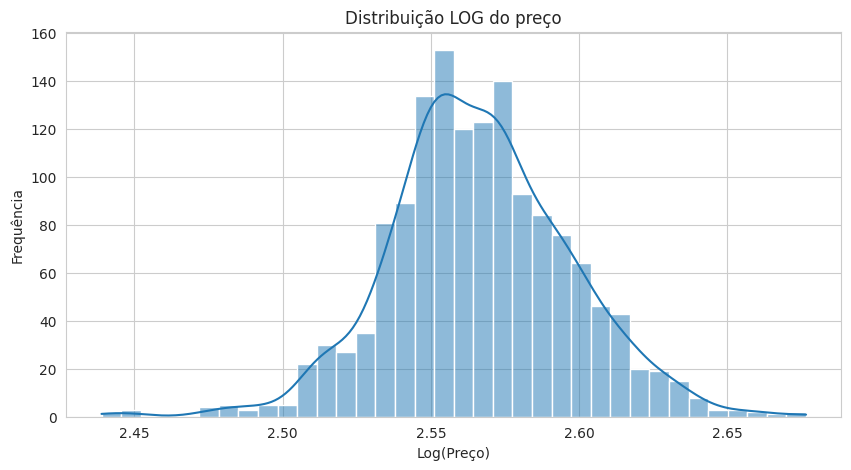

In [43]:
# testar formação log
plt.figure(figsize=(10,5))

sns.histplot(np.log1p(y), kde=True)
# log1p = transforma os valores para reduzir distorções (melhora modelo)

plt.title("Distribuição LOG do preço")
plt.xlabel("Log(Preço)")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()

In [44]:
# ANALISAR CORRELAÇÃO COM O PREÇO

df_corr = X.copy()
# cria uma cópia dos dados de entrada (X)
# importante para não modificar o dataset original

df_corr['SalePrice'] = y
# adiciona o target (preço) de volta ao dataset
# precisamos disso para calcular correlação com as outras variáveis

corr = df_corr.corr(numeric_only=True)
# calcula a matriz de correlação
# numeric_only=True = usa apenas colunas numéricas (ignora texto)

top_corr = corr['SalePrice'].sort_values(ascending=False)[1:11]
# pega as correlações com o preço
# sort_values = ordena do maior para o menor
# [1:11] = remove o próprio SalePrice (que é 1.0) e pega as próximas 10

print(top_corr)
# mostra as 10 variáveis mais relacionadas com o preço

OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
Name: SalePrice, dtype: float64


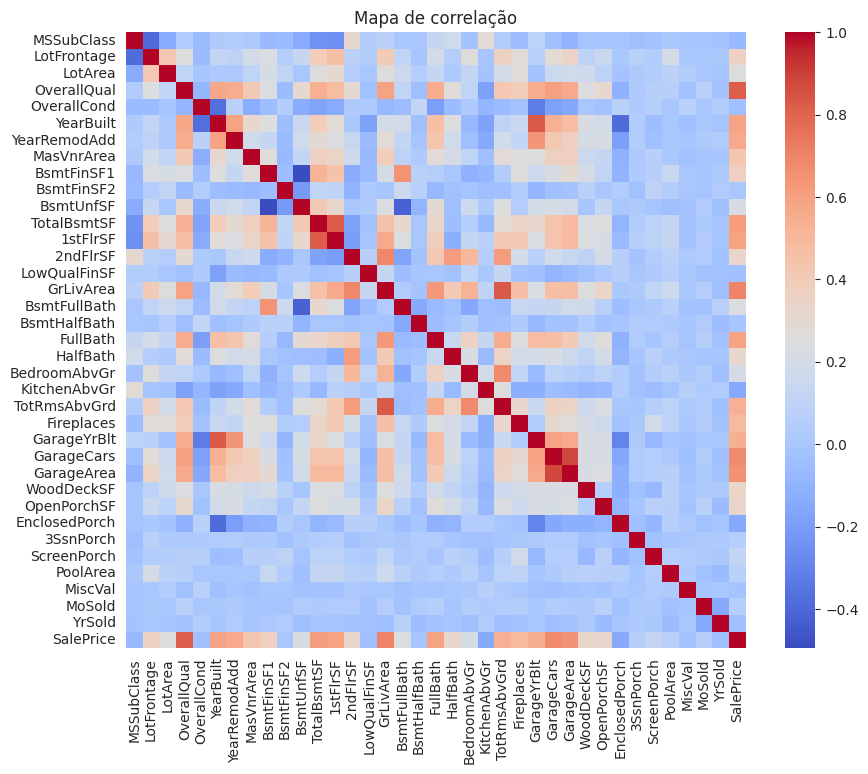

In [45]:
#HEATMAP
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Mapa de correlação")
plt.show()

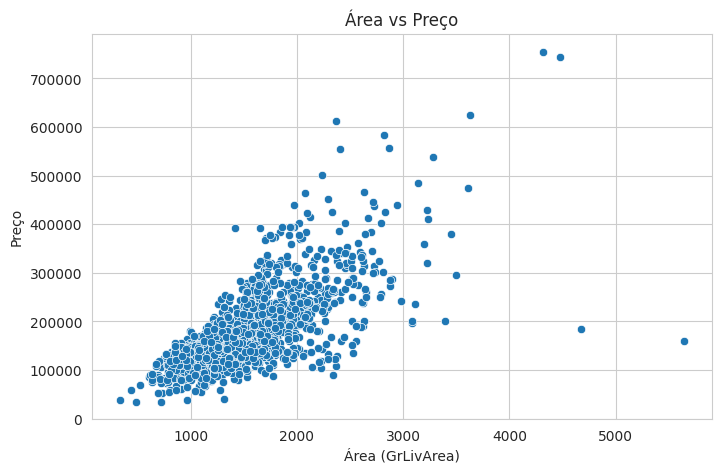

In [46]:
# GRÁFICO: ÁREA VS PREÇO

plt.figure(figsize=(8,5))
# define o tamanho do gráfico

sns.scatterplot(x=X['GrLivArea'], y=np.expm1(y))
# expm1 = volta do log para o valor original

plt.title("Área vs Preço")
plt.xlabel("Área (GrLivArea)")
plt.ylabel("Preço")

plt.show()

In [47]:
#SPLIT
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    train_size=0.8,
    random_state=0
)

In [48]:
#FEATURE SELECTION
low_cardinality_cols = [
    c for c in X_train.columns
    if X_train[c].nunique() < 10 and X_train[c].dtype == "object"
]

numeric_cols = [
    c for c in X_train.columns
    if X_train[c].dtype in ['int64', 'float64']
]

my_cols = low_cardinality_cols + numeric_cols

In [49]:
#ENCODING
X_train = X_train[my_cols].copy()
X_valid = X_valid[my_cols].copy()
X_test = X_test_full[my_cols].copy()

# ONE-HOT ENCODING
X_train = pd.get_dummies(X_train)
X_valid = pd.get_dummies(X_valid)
X_test = pd.get_dummies(X_test)

# ALINHAR COLUNAS
X_train, X_valid = X_train.align(X_valid, join='left', axis=1)
X_train, X_test = X_train.align(X_test, join='left', axis=1)

In [50]:
#BASELINE — RANDOM FOREST
rf = RandomForestRegressor(random_state=0)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_valid)
rf_mae = mean_absolute_error(rf_preds, y_valid)

print("Random Forest MAE:", rf_mae)

#para corrigir o log
rf_preds_exp = np.expm1(rf_preds)
y_valid_exp = np.expm1(y_valid)
rf_mae_real = mean_absolute_error(rf_preds_exp, y_valid_exp)
print("Random Forest MAE (valor real):", rf_mae_real)

Random Forest MAE: 0.09222672592551466
Random Forest MAE (valor real): 17860.057311553894


In [51]:
#XGBOOST
xgb = XGBRegressor (
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0
)
xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_valid)
xgb_mae = mean_absolute_error(xgb_preds, y_valid)

print("XGBoost MAE:", xgb_mae)

#para corrigir o log
xgb_preds_real = np.expm1(xgb_preds)
y_valid_real = np.expm1(y_valid)
xgb_mae_real = mean_absolute_error(xgb_preds_real, y_valid_real)
print("XGBoost MAE (valor real):", xgb_mae_real)

XGBoost MAE: 0.08511242289108095
XGBoost MAE (valor real): 15419.831442637


100 estimators MAE: 177872.5661071777
500 estimators MAE: 177855.77562665544
1000 estimators MAE: 177322.65415833352
Melhor: 1000


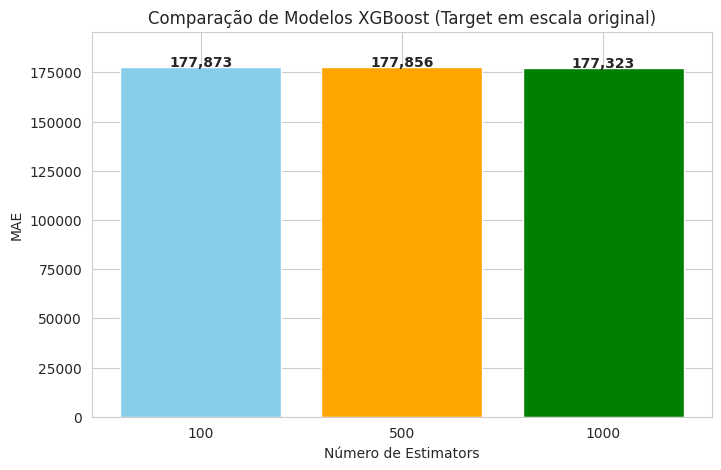

In [52]:
#EXPERIMENTAR
models = {
    "100": XGBRegressor(n_estimators=100, learning_rate=0.05),
    "500": XGBRegressor(n_estimators=500, learning_rate=0.05),
    "1000": XGBRegressor(n_estimators=1000, learning_rate=0.05)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds_log = model.predict(X_valid)
    mae = mean_absolute_error(preds, y_valid)
    preds = np.expm1(preds_log)  # expm1 = exp(x) - 1
    mae = mean_absolute_error(y_valid, preds)  # agora MAE é na escala origina

    results[name] = mae
    print(f"{name} estimators MAE: {mae}")

best_model = min(results, key=results.get)
print("Melhor:", best_model)
final_model = models[best_model]
final_model.fit(X_train, y_train)
preds_test_log = final_model.predict(X_test)
preds_test = np.expm1(preds_test_log)  # converter para escala original

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'orange', 'green'])
plt.title("Comparação de Modelos XGBoost (Target em escala original)")
plt.xlabel("Número de Estimators")
plt.ylabel("MAE")
plt.ylim(0, max(results.values())*1.1)
for i, v in enumerate(results.values()):
    plt.text(i, v + 100, f"{v:,.0f}", ha='center', fontweight='bold')
plt.show()


In [53]:
#SUBMISSÃO
output = pd.DataFrame({
    'Id': X_test.index,
    'SalePrice': preds_test
})

output.to_csv('submission.csv', index=False)
print("Arquivo submission.csv gerado com sucesso!")

Arquivo submission.csv gerado com sucesso!
